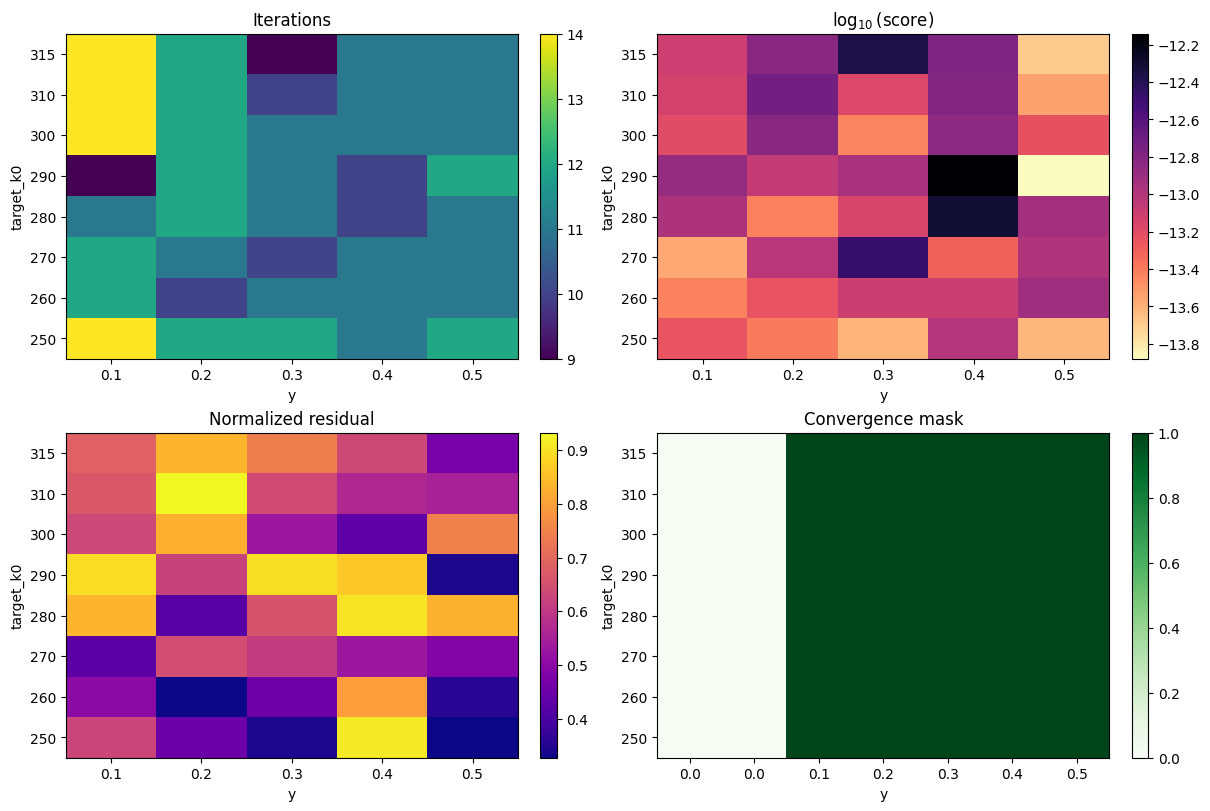

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv(
    "/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_finite_temperature_fixed_y/asymmetric_clausius_fixed_y_tc_nc.csv"
)

status = pd.read_csv(
    "/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_finite_temperature_fixed_y/asymmetric_clausius_fixed_y_branch_status.csv"
)

tol_dPdn = 1.0e-5
tol_d2Pdn2 = 1.0e-4

results["norm_residual"] = np.maximum(
    np.abs(results["dPdn"]) / tol_dPdn,
    np.abs(results["d2Pdn2"]) / tol_d2Pdn2,
)

results["log10_score"] = np.log10(results["score"].clip(lower=1e-30))

status["ok"] = (status["status"] == "converged").astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

maps = [
    ("iterations", "Iterations", axes[0, 0], "viridis"),
    ("log10_score", r"$\log_{10}(\mathrm{score})$", axes[0, 1], "magma_r"),
    ("norm_residual", "Normalized residual", axes[1, 0], "plasma"),
]

for col, title, ax, cmap in maps:
    pivot = results.pivot(index="target_k0", columns="y", values=col).sort_index()
    im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.1f}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{x:.0f}" for x in pivot.index])
    ax.set_xlabel("y")
    ax.set_ylabel("target_k0")
    fig.colorbar(im, ax=ax)

pivot = status.pivot(index="target_k0", columns="y", values="ok").sort_index()
im = axes[1, 1].imshow(pivot.values, aspect="auto", origin="lower", cmap="Greens", vmin=0, vmax=1)
axes[1, 1].set_title("Convergence mask")
axes[1, 1].set_xticks(range(len(pivot.columns)))
axes[1, 1].set_xticklabels([f"{x:.1f}" for x in pivot.columns])
axes[1, 1].set_yticks(range(len(pivot.index)))
axes[1, 1].set_yticklabels([f"{x:.0f}" for x in pivot.index])
axes[1, 1].set_xlabel("y")
axes[1, 1].set_ylabel("target_k0")
fig.colorbar(im, ax=axes[1, 1])

plt.show()